In [6]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.preprocessing import MinMaxScaler
from skimage.metrics import structural_similarity as ssim
from math import log10
import json
import os
import time
import json
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim

import models
from processdata import TimeSeriesDataset

In [7]:
# Define os caminhos de salvamento e carregamento
# save_path = r"./results/csshred/testes"
# load_path = r"./results/csshred/testes"
save_path = r"/home/romulo/Documentos/lpips-env/home/romulo/Documentos/lpips-env/results/csshred/piv"
load_path = r"/home/romulo/Documentos/lpips-env/home/romulo/Documentos/lpips-env/results/csshred/piv"

# Carrega os arquivos necessários
test_recons = np.load(load_path + r"/test_recons.npy")
test_ground_truth = np.load(load_path + r"/test_ground_truth.npy")
matrix = np.load(load_path + r"/matrix.npy")
snapshot = np.load(load_path + r"/snapshot.npy")
sensor_positions_x = np.load(load_path + r"/sensor_positions_x.npy")
sensor_positions_y = np.load(load_path + r"/sensor_positions_y.npy")
train_error = np.load(load_path + r"/train_error.npy")
validation_errors = np.load(load_path + r"/validation_errors.npy")

In [8]:
import json
import os
import numpy as np
from math import log10
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim

def plot_results(
    train_error, validation_errors, test_recons, test_ground_truth, matrix, subsampled,
    save_path=r'./results/csshred/piv/'
):
    # Certifique-se de que o diretório de salvamento existe
    os.makedirs(save_path, exist_ok=True)
    
    dim_x, dim_y, dim_t = subsampled.shape

    # Reorganizar os dados mantendo a transposta para visualização
    test_ground_truth = test_ground_truth.copy().reshape(-1, dim_x, dim_y)
    test_ground_truth = np.transpose(test_ground_truth.copy(), (1, 2, 0))
    test_recons = test_recons.reshape(-1, dim_x, dim_y)
    subsampled = subsampled.reshape(dim_x, dim_y, -1)

    print("test_recons shape:", test_recons.shape)
    print("test_ground_truth shape:", test_ground_truth.shape)
    print("subsampled shape:", subsampled.shape)

    # Plot Training Error
    plt.figure(figsize=(12, 6))
    plt.plot(train_error, label="Training Error")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Error Over Epochs")
    plt.legend()
    plt.savefig(os.path.join(save_path, "training_error.png"))
    plt.show()

    # Plot Validation Error
    plt.figure(figsize=(12, 6))
    plt.plot(validation_errors, label="Validation Error")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Validation Error Over Epochs")
    plt.legend()
    plt.savefig(os.path.join(save_path, "validation_error.png"))
    plt.show()

    # Plot Last Snapshot - Reconstructed and Original
    plt.figure(figsize=(14, 6))

    ax1 = plt.subplot(1, 2, 1)
    img1 = ax1.imshow(test_recons[-1], cmap='RdBu_r', interpolation='bilinear')
    plt.colorbar(img1, ax=ax1)
    ax1.set_title("Reconstructed - Last Snapshot")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    
    ax2 = plt.subplot(1, 2, 2)
    img2 = ax2.imshow(test_ground_truth[:, :, -1], cmap='RdBu_r', interpolation='bilinear')
    plt.colorbar(img2, ax=ax2)
    ax2.set_title("Original - Last Snapshot")
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, "last_snapshot_comparison.png"))
    plt.show()

    # Plot Last Snapshot - Reconstructed and Subsampled
    plt.figure(figsize=(14, 6))
    
    ax3 = plt.subplot(1, 2, 1)
    img3 = ax3.imshow(test_recons[-1], cmap='RdBu_r', interpolation='bilinear')
    plt.colorbar(img3, ax=ax3)
    ax3.set_title("Reconstructed - Last Snapshot")
    ax3.set_xlabel("X")
    ax3.set_ylabel("Y")
    
    ax4 = plt.subplot(1, 2, 2)
    img4 = ax4.imshow(subsampled[:, :, -1], cmap='RdBu_r', interpolation='bilinear')
    plt.colorbar(img4, ax=ax4)
    ax4.set_title("Subsampled - Last Snapshot")
    ax4.set_xlabel("X")
    ax4.set_ylabel("Y")
    
    plt.tight_layout()
    plt.savefig(os.path.join(save_path, "subsampled_snapshot_comparison.png"))
    plt.show()
    
    # Calculando métricas
    ssim_value_last = ssim(
        test_ground_truth[:, :, -1],
        test_recons[-1],
        data_range=test_ground_truth[:, :, -1].max() - test_ground_truth[:, :, -1].min(),
    )
    
    test_recons_mse = np.transpose(test_recons.copy(), (1,2,0))
    mse_value_last = np.linalg.norm(test_recons_mse - test_ground_truth) / np.linalg.norm(test_ground_truth)
    
    mse = mean_squared_error(test_ground_truth[:, :, -1], test_recons[-1])
    max_pixel = np.max(test_ground_truth[:, :, -1])
    psnr_value_last = 20 * log10(max_pixel / np.sqrt(mse))
    
    print(f"SSIM for the last snapshot: {ssim_value_last}")
    print(f"MSE for the last snapshot: {mse_value_last}")
    print(f"PSNR for the last snapshot: {psnr_value_last} dB")
    
    # Calculando médias para todos os snapshots
    ssim_values = []
    psnr_values = []
    for i in range(test_recons.shape[0]):
        ssim_value = ssim(
            test_ground_truth[:, :, i],
            test_recons[i],
            data_range=test_ground_truth[:, :, i].max() - test_ground_truth[:, :, i].min(),
        )
        ssim_values.append(ssim_value)
        
        mse = mean_squared_error(test_ground_truth[:, :, i], test_recons[i])
        max_pixel = np.max(test_ground_truth[:, :, i])
        psnr = 20 * log10(max_pixel / np.sqrt(mse))
        psnr_values.append(psnr)
    
    mean_ssim_value = np.mean(ssim_values)
    mean_psnr_value = np.mean(psnr_values)
    print(f"Mean SSIM for all snapshots: {mean_ssim_value}")
    print(f"Mean PSNR for all snapshots: {mean_psnr_value} dB")

    # Salvando resultados em JSON
    results = {
        "SSIM_last_snapshot": float(ssim_value_last),
        "MSE_last_snapshot": float(mse_value_last),
        "PSNR_last_snapshot": float(psnr_value_last),
        "Mean_SSIM_all_snapshots": float(mean_ssim_value),
        "Mean_PSNR_all_snapshots": float(mean_psnr_value),
    }
    
    json_file_path = os.path.join(save_path, "results.json")
    with open(json_file_path, "w") as json_file:
        json.dump(results, json_file, indent=4)
    
    print(f"Results saved to {json_file_path}")
    print(f"Plots saved to {save_path}")

test_recons shape: (26, 256, 257)
test_ground_truth shape: (256, 257, 26)
subsampled shape: (256, 257, 280)


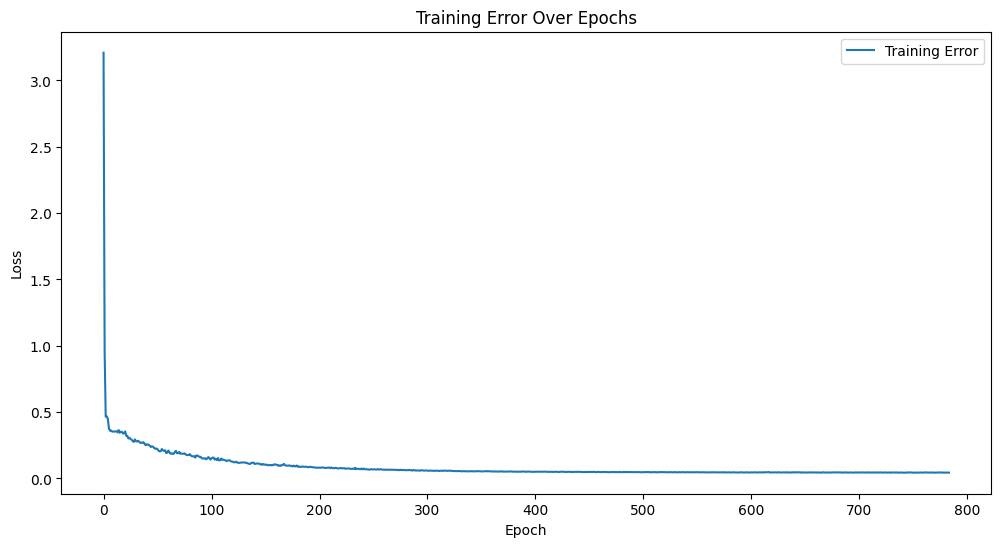

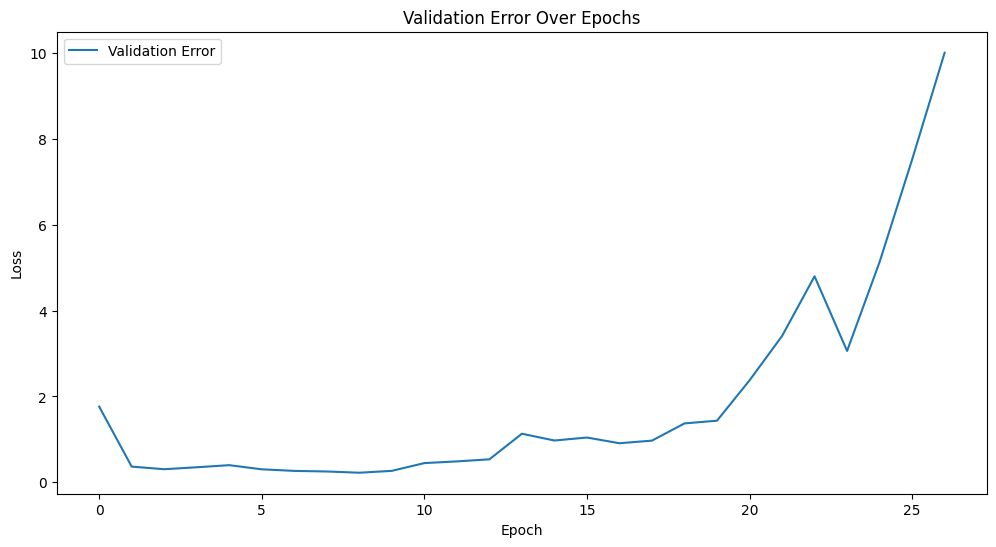

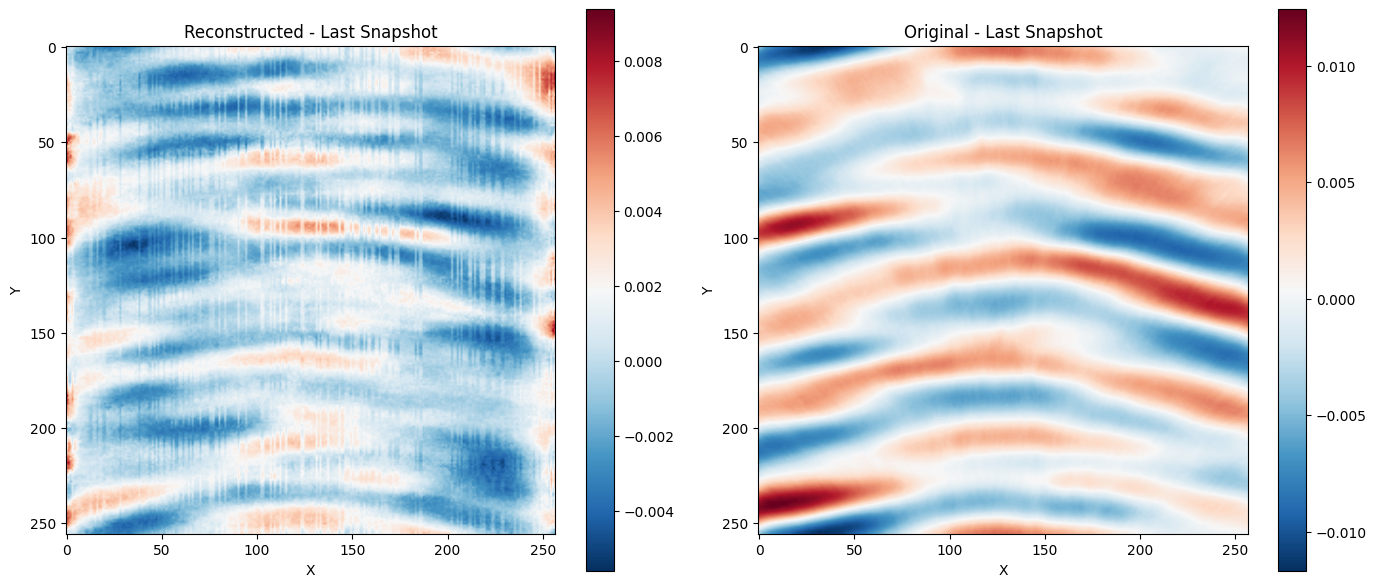

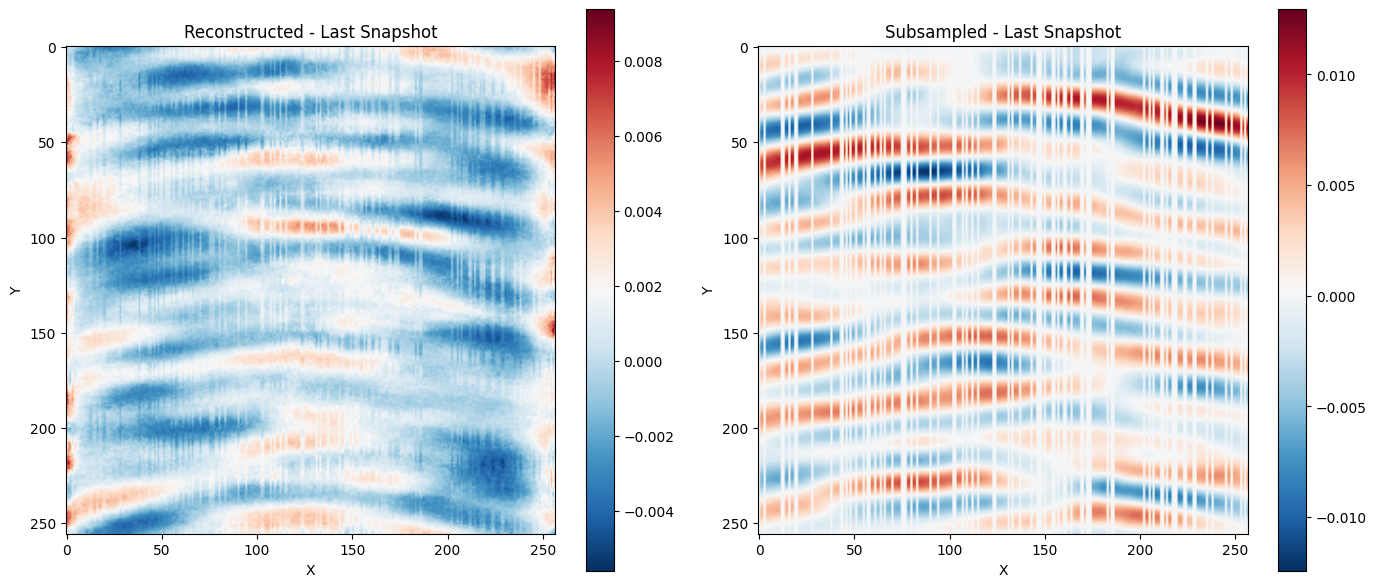

SSIM for the last snapshot: 0.045642895688579314
MSE for the last snapshot: 1.0544956922531128
PSNR for the last snapshot: 9.912271733333704 dB
Mean SSIM for all snapshots: 0.060488398044097225
Mean PSNR for all snapshots: 10.225311018037704 dB
Results saved to ./results/csshred/piv/results.json
Plots saved to ./results/csshred/piv/


In [9]:
plot_results(train_error, validation_errors, test_recons, test_ground_truth, matrix, snapshot)